<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:36px 40px;border-radius:12px;margin-bottom:8px;">
  <div style="display:flex;align-items:center;gap:16px;">
    <span style="font-size:48px;">🛰️</span>
    <div>
      <p style="color:#ADE8F4;margin:0;font-size:13px;letter-spacing:3px;text-transform:uppercase;font-family:monospace;">Computer Vision for Remote Sensing · Bangladesh</p>
      <h1 style="color:#FFFFFF;margin:4px 0 0 0;font-size:28px;font-family:monospace;">Phase 1 · Raster CV Foundations</h1>
    </div>
  </div>
  <hr style="border-color:#1E88E5;margin:20px 0 16px 0;"/>
  <div style="display:flex;gap:32px;flex-wrap:wrap;">
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📘 Lesson <b style="color:#FFF">L5 / 7</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">⏱ Est. Time <b style="color:#FFF">4 hrs</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📍 Study Area <b style="color:#FFF">Sitakunda</b></span>
    <span style="color:#90CAF9;font-family:monospace;font-size:13px;">📅 Date <b style="color:#FFF">____-__-__</b></span>
  </div>
</div>
<div style="background:#1565C022;border-left:5px solid #1565C0;padding:18px 24px;border-radius:0 8px 8px 0;">
  <h2 style="color:#1565C0;margin:0 0 8px 0;font-size:18px;">📖 L5 — Patch Tiling for ML</h2>
  <p style="margin:0;color:#1A2A3A;font-size:14px;">📝 <i>Add lesson description here — what is this lesson about?</i></p>
</div>

## 🎯 Objectives

By the end of this lesson you will be able to:

- ✅ _Objective 1_
- ✅ _Objective 2_
- ✅ _Objective 3_

---

## 🔑 Key Functions

| Function | Purpose |
|---|---|
| `function()` | description |


---
## ⚙️ Setup & Imports

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# ── Paths (local only — data not pushed to GitHub) ────────────────────────
DATA_DIR = pathlib.Path('../../data/raw/')
FIG_DIR  = pathlib.Path('../../outputs/figures/phase1/')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TIF_PATH = DATA_DIR / 'sitakunda_sentinel2.tif'   # ← change to your file
print(f'File found: {TIF_PATH.exists()}')

File found: False


---
## 1 · _Section Title_

> 📝 Add explanation here.

In [1]:
import rasterio

url = "https://raw.githubusercontent.com/rasterio/rasterio/master/tests/data/RGB.byte.tif"

with rasterio.open(url) as src:
    print(src.width, src.height, src.count, src.crs)

791 718 3 EPSG:32618


---
## 🏋️ Exercise

<div style="background:#FFF9C4;border-left:4px solid #F9A825;padding:14px 20px;border-radius:0 8px 8px 0;">
<b>Task:</b> Patch Tiling for ML — complete the exercise below.
</div>

In [2]:
# ── Cell 2: Read the full image as an array ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(url) as src:
    image = src.read()           # shape: (3, 718, 791)
    transform = src.transform
    profile = src.profile

print(f"Image shape  : {image.shape}  → (bands, height, width)")
print(f"dtype        : {image.dtype}")
print(f"Value range  : {image.min()} → {image.max()}")
print(f"Pixel size   : {src.res[0]:.2f}m × {src.res[1]:.2f}m")

Image shape  : (3, 718, 791)  → (bands, height, width)
dtype        : uint8
Value range  : 0 → 255
Pixel size   : 300.04m × 300.04m


In [11]:
# ── Cell 3: Extract patches ────────────────────────────────────────────────
PATCH_SIZE = 128    # smaller since sample image is only 791×718
STRIDE     = 128    # no overlap

def extract_patches(image, patch_size, stride):
    """
    Slice a (C, H, W) image into fixed-size patches.
    Skips patches with more than 20% zero pixels.
    Returns list of (C, patch_size, patch_size) arrays.
    """
    C, H, W  = image.shape
    patches  = []
    coords   = []

    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            patch = image[:, r:r+patch_size, c:c+patch_size]

            # ── Skip empty / nodata patches ───────────────────────────────
            zero_ratio = (patch == 0).sum() / patch.size
            if zero_ratio > 0.20:
                continue

            patches.append(patch.astype(np.float32))
            coords.append((r, c))

    return patches, coords

patches, coords = extract_patches(image, PATCH_SIZE, STRIDE)

print(f"Patches extracted  : {len(patches)}")
print(f"Each patch shape   : {patches[0].shape}  → (3, 128, 128)")
print(f"Memory per patch   : {patches[0].nbytes / 1024:.1f} KB")
print(f"Non-zero check     : min={patches[0].min():.0f}  max={patches[0].max():.0f}")

Patches extracted  : 18
Each patch shape   : (3, 128, 128)  → (3, 128, 128)
Memory per patch   : 192.0 KB
Non-zero check     : min=0  max=255


In [13]:
# ── Cell 4: Normalize patches (0 to 1) ────────────────────────────────────
# In RS imagery values are often DN (0-255 for byte, or 0-65535 for uint16)
# Normalise per-patch to [0, 1] for ML input

def normalize_patch(patch):
    """Min-max normalize each band independently."""
    out = np.zeros_like(patch, dtype=np.float32)
    for b in range(patch.shape[0]):
        band = patch[b].astype(np.float32)
        bmin, bmax = band.min(), band.max()
        if bmax > bmin:
            out[b] = (band - bmin) / (bmax - bmin)
        else:
            out[b] = 0.0
    return out

norm_patches = [normalize_patch(p) for p in patches]

print(f"Before norm: min={patches[0].min():.0f}  max={patches[0].max():.0f}")
print(f"After norm : min={norm_patches[0].min():.3f}  max={norm_patches[0].max():.3f}")

Before norm: min=0  max=255
After norm : min=0.000  max=1.000


In [14]:
# ── Cell 5: Save patches as .npy files ────────────────────────────────────
import pathlib, json

PATCH_DIR = pathlib.Path("../../outputs/patches")
PATCH_DIR.mkdir(parents=True, exist_ok=True)

for i, patch in enumerate(norm_patches):
    np.save(PATCH_DIR / f"patch_{i:04d}.npy", patch)

# Save coords
np.save(PATCH_DIR / "coords.npy", np.array(coords))

# Save metadata
meta = {
    "patch_size"   : PATCH_SIZE,
    "stride"       : STRIDE,
    "n_bands"      : image.shape[0],
    "total_patches": len(norm_patches),
    "source"       : "RGB.byte.tif (sample)"
}
with open(PATCH_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"✅ {len(norm_patches)} patches saved to {PATCH_DIR}")

# ── Quick load test ────────────────────────────────────────────────────────
test = np.load(PATCH_DIR / "patch_0000.npy")
print(f"Load test  : shape={test.shape}  dtype={test.dtype}  ✅")

✅ 18 patches saved to ..\..\outputs\patches
Load test  : shape=(3, 128, 128)  dtype=float32  ✅


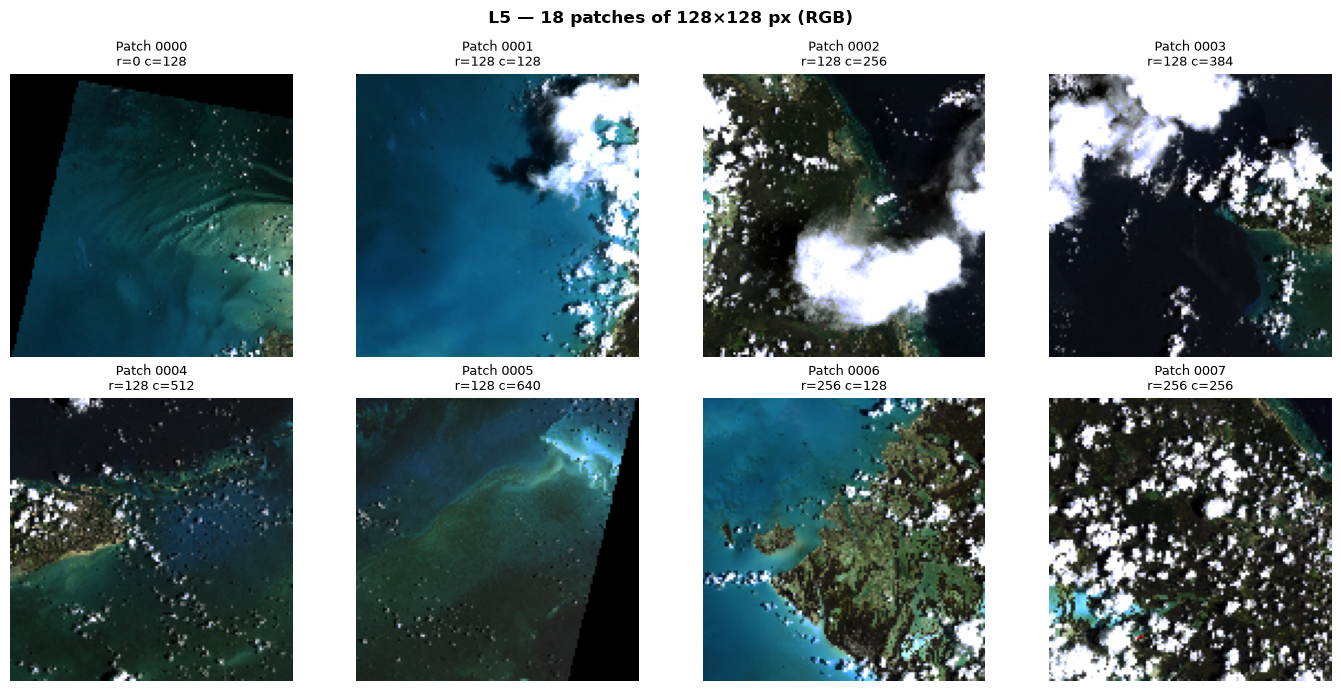

✅ Figure saved


In [15]:
# ── Cell 6: Visualise patches ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(norm_patches):
        ax.axis("off")
        continue

    patch = norm_patches[i]
    rgb   = np.moveaxis(patch[[0, 1, 2], :, :], 0, -1)  # → (H, W, 3)
    rgb   = np.clip(rgb, 0, 1)

    ax.imshow(rgb)
    ax.set_title(f"Patch {i:04d}\nr={coords[i][0]} c={coords[i][1]}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"L5 — {len(norm_patches)} patches of {PATCH_SIZE}×{PATCH_SIZE} px (RGB)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/phase1/L5_patches.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Figure saved")

In [17]:
# ── Cell 7: Summary ───────────────────────────────────────────────────────
print("=" * 50)
print("L5 COMPLETE — Patch Tiling")
print("=" * 50)
print(f"  Source image   : 791×718, 3 bands")
print(f"  Patch size     : {PATCH_SIZE}×{PATCH_SIZE} px")
print(f"  Stride         : {STRIDE} px (no overlap)")
print(f"  Total patches  : {len(norm_patches)}")
print(f"  Patch shape    : {norm_patches[0].shape}")
print(f"  Saved to       : outputs/patches/")
print(f"\n  HOW TO LOAD IN PyTorch (L6 preview):")
print(f"    patch = np.load('patch_0000.npy')")
print(f"    tensor = torch.from_numpy(patch)  # shape (3,128,128)")
print("=" * 50)

L5 COMPLETE — Patch Tiling
  Source image   : 791×718, 3 bands
  Patch size     : 128×128 px
  Stride         : 128 px (no overlap)
  Total patches  : 18
  Patch shape    : (3, 128, 128)
  Saved to       : outputs/patches/

  HOW TO LOAD IN PyTorch (L6 preview):
    patch = np.load('patch_0000.npy')
    tensor = torch.from_numpy(patch)  # shape (3,128,128)


---
## 📝 My Notes

> _Fill in after completing the exercise._

- Observation 1: `____`
- Observation 2: `____`
- Anything unexpected: `____`


---
<div style="background:linear-gradient(135deg,#0D1B2A 0%,#1565C0 100%);padding:24px 32px;border-radius:10px;">
  <h2 style="color:#FFFFFF;margin:0 0 12px 0;font-size:18px;">✅ Key Takeaways — L5</h2>
  <ul style="color:#C8E6C9;font-size:14px;line-height:2.2;margin:0;">
    <li>_Takeaway 1_</li>
    <li>_Takeaway 2_</li>
    <li>_Takeaway 3_</li>
  </ul>
</div>

---
<div style="display:flex;justify-content:space-between;padding:10px 0;font-size:13px;color:#9E9E9E;">
  <span>← Previous: <a href="L4_prev.ipynb">L4</a></span>
  <b style="color:#1565C0;">Phase 1 · L5 of 7</b>
  <span><a href="L6_next.ipynb" style="color:#1565C0;">Next: L6 →</a></span>
</div>